# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]

## Inicialização

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats



## Carregue os dados

In [ ]:
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


print("CALLS")
display(calls.head())
print("INTERNET")
display(internet.head())
print("MESSAGES")
display(messages.head())
print("PLANS")
display(plans.head())
print("USERS")
display(users.head())



CALLS


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


INTERNET


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


MESSAGES


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


PLANS


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


USERS


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Planos

In [ ]:
plans.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:

plans.head()




,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]  Se analisarmos a saída de plans.info() e da amostra com .head(), não há problemas óbvios nos dados do DataFrame plans, não ha valores ausentes e os tipos de dados estão adequados. Oque se pode fazer apenas como precaução, é:

Garantir que mb_per_month_included seja convertido para GB em uma nova coluna, já que a cobrança extra é em GB (isso não corrige um erro, apenas facilita cálculos futuros).

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:

plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:
 plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Usuários

In [ ]:
users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:


users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]  O principal problema é a coluna reg_date, que provavelmente está como object (string) em vez de datetime. O mesmo vale para churn_date — e como os usuários ativos não têm data de cancelamento, ela aparece como NaT (equivalente a nulo para datas), o que é esperado e correto

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:

users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])

print(users.isna().sum())

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:

users['state'] = users['city'].str.extract(r'(\w{2})\s+MSA')

users['age_group'] = pd.cut(users['age'], 
                             bins=[0, 25, 35, 45, 55, 100],
                             labels=['18-25', '26-35', '36-45', '46-55', '55+'])
users['months_active'] = (
    (users['churn_date'].fillna(pd.Timestamp('2018-12-31')) - users['reg_date'])
    .dt.days // 30
)

print("Novas colunas adicionadas:")
print(users[['user_id', 'city', 'state', 'age', 'age_group', 'reg_date', 'churn_date', 'months_active']].head())
print()


Novas colunas adicionadas:
   user_id                                   city state  age age_group  \
0     1000  Atlanta-Sandy Springs-Roswell, GA MSA    GA   45     36-45   
1     1001        Seattle-Tacoma-Bellevue, WA MSA    WA   28     26-35   
2     1002   Las Vegas-Henderson-Paradise, NV MSA    NV   36     36-45   
3     1003                          Tulsa, OK MSA    OK   52     46-55   
4     1004        Seattle-Tacoma-Bellevue, WA MSA    WA   40     36-45   

    reg_date churn_date  months_active  
0 2018-12-24        NaT              0  
1 2018-08-13        NaT              4  
2 2018-10-21        NaT              2  
3 2018-01-28        NaT             11  
4 2018-05-23        NaT              7  



## Chamadas

In [ ]:
calls.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
calls.head()



,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?] call_date está como object (string) quando deveria ser datetime, para permitir extrair mês e ano nas agregações futuras.
id está como object — provavelmente é um identificador único e não será usado nos cálculos, mas vale converter para manter consistência.
duration está como float64, o que faz sentido pois a duração pode ter casas decimais. Porém, a Megaline arredonda para cima cada chamada (minutos inteiros cobrados), então precisaremos aplicar ceil() no momento do cálculo de receita.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:

# Corrigindo tipo da data e extraindo o mês
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['month'] = calls['call_date'].dt.month

# Arredondando duração para cima (regra da Megaline)
calls['duration'] = calls['duration'].apply(math.ceil)

print(calls.info())
print()
print(calls.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
 4   month      137735 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 5.3+ MB
None

         id  user_id  call_date  duration  month
0   1000_93     1000 2018-12-27         9     12
1  1000_145     1000 2018-12-27        14     12
2  1000_247     1000 2018-12-27        15     12
3  1000_309     1000 2018-12-28         6     12
4  1000_380     1000 2018-12-30         5     12


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:

calls['year'] = calls['call_date'].dt.year


print("DataFrame de chamadas enriquecido:")
print(calls.head())
print()
print(f"Total de registros: {len(calls)}")
print(f"Período coberto: {calls['call_date'].min()} a {calls['call_date'].max()}")

DataFrame de chamadas enriquecido:
         id  user_id  call_date  duration  month  year
0   1000_93     1000 2018-12-27         9     12  2018
1  1000_145     1000 2018-12-27        14     12  2018
2  1000_247     1000 2018-12-27        15     12  2018
3  1000_309     1000 2018-12-28         6     12  2018
4  1000_380     1000 2018-12-30         5     12  2018

Total de registros: 137735
Período coberto: 2018-01-15 00:00:00 a 2018-12-31 00:00:00


## Mensagens

In [ ]:
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
messages.head()



,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [ ]:
#Problemas encontrados:
#message_date está como object (string) quando deveria ser datetime, para permitir extrair o mês nas agregações futuras.
#id está como object, o que é aceitável por ser apenas um identificador.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:

messages['message_date'] = pd.to_datetime(messages['message_date'])

print(messages.info())
print()
print(messages.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:

messages['month'] = messages['message_date'].dt.month
messages['year'] = messages['message_date'].dt.year

print("DataFrame de mensagens enriquecido:")
print(messages.head())
print()
print(f"Total de registros: {len(messages)}")
print(f"Período coberto: {messages['message_date'].min()} a {messages['message_date'].max()}")

DataFrame de mensagens enriquecido:
         id  user_id message_date  month  year
0  1000_125     1000   2018-12-27     12  2018
1  1000_160     1000   2018-12-31     12  2018
2  1000_223     1000   2018-12-31     12  2018
3  1000_251     1000   2018-12-27     12  2018
4  1000_255     1000   2018-12-26     12  2018

Total de registros: 76051
Período coberto: 2018-01-15 00:00:00 a 2018-12-31 00:00:00


## Internet

In [ ]:
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
internet.head()



,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?] session_date está como object (string) quando deveria ser datetime, para permitir extrair o mês nas agregações futuras.
mb_used está como float64 com casas decimais (89.86, 660.40...). Assim como as chamadas, a Megaline arredonda para cima o consumo de dados em GB, então precisaremos aplicar ceil() no momento do cálculo de receita.
id está como object, aceitável por ser apenas um identificador.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:


internet['session_date'] = pd.to_datetime(internet['session_date'])
internet['mb_used'] = internet['mb_used'].apply(math.ceil)

print(internet.info())
print()
print(internet.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.2+ MB
None

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29       90
1  1000_204     1000   2018-12-31        0
2  1000_379     1000   2018-12-28      661
3  1000_413     1000   2018-12-26      271
4  1000_442     1000   2018-12-27      881


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:
# Extraindo mês e ano para agregações futuras
internet['month'] = internet['session_date'].dt.month
internet['year'] = internet['session_date'].dt.year

# Convertendo MB para GB para facilitar cálculo de receita
internet['gb_used'] = internet['mb_used'] / 1024

print("DataFrame de internet enriquecido:")
print(internet.head())
print()
print(f"Total de registros: {len(internet)}")
print(f"Período coberto: {internet['session_date'].min()} a {internet['session_date'].max()}")

DataFrame de internet enriquecido:
         id  user_id session_date  mb_used  month  year   gb_used
0   1000_13     1000   2018-12-29       90     12  2018  0.087891
1  1000_204     1000   2018-12-31        0     12  2018  0.000000
2  1000_379     1000   2018-12-28      661     12  2018  0.645508
3  1000_413     1000   2018-12-26      271     12  2018  0.264648
4  1000_442     1000   2018-12-27      881     12  2018  0.860352

Total de registros: 104825
Período coberto: 2018-01-15 00:00:00 a 2018-12-31 00:00:00


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [ ]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
print("Condições dos planos:")
print(plans[['plan_name', 'usd_monthly_pay', 'minutes_included', 
             'messages_included', 'mb_per_month_included',
             'usd_per_minute', 'usd_per_message', 'usd_per_gb']].to_string(index=False))



Condições dos planos:
plan_name  usd_monthly_pay  minutes_included  messages_included  mb_per_month_included  usd_per_minute  usd_per_message  usd_per_gb
     surf               20               500                 50                  15360            0.03             0.03          10
 ultimate               70              3000               1000                  30720            0.01             0.01           7


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [ ]:

calls_per_user_month = calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_per_user_month.columns = ['user_id', 'month', 'calls_count']

print("Número de chamadas por usuário por mês:")
print(calls_per_user_month.head(10))

Número de chamadas por usuário por mês:
   user_id  month  calls_count
0     1000     12           16
1     1001      8           27
2     1001      9           49
3     1001     10           65
4     1001     11           64
5     1001     12           56
6     1002     10           11
7     1002     11           55
8     1002     12           47
9     1003     12          149


In [ ]:
minutes_per_user_month = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
minutes_per_user_month.columns = ['user_id', 'month', 'minutes_used']

print("Quantidade de minutos por usuário por mês:")
print(minutes_per_user_month.head(10))

Quantidade de minutos por usuário por mês:
   user_id  month  minutes_used
0     1000     12           124
1     1001      8           182
2     1001      9           315
3     1001     10           393
4     1001     11           426
5     1001     12           412
6     1002     10            59
7     1002     11           386
8     1002     12           384
9     1003     12          1104


In [ ]:
messages_per_user_month = messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_per_user_month.columns = ['user_id', 'month', 'messages_count']

print("Número de mensagens por usuário por mês:")
print(messages_per_user_month.head(10))



Número de mensagens por usuário por mês:
   user_id  month  messages_count
0     1000     12              11
1     1001      8              30
2     1001      9              44
3     1001     10              53
4     1001     11              36
5     1001     12              44
6     1002     10              15
7     1002     11              32
8     1002     12              41
9     1003     12              50


In [ ]:

internet_per_user_month = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
internet_per_user_month.columns = ['user_id', 'month', 'mb_used']

print("Volume de internet por usuário por mês:")
print(internet_per_user_month.head(10))

Volume de internet por usuário por mês:
   user_id  month  mb_used
0     1000     12     1903
1     1001      8     6929
2     1001      9    13333
3     1001     10    22356
4     1001     11    18524
5     1001     12    19398
6     1002     10     6559
7     1002     11    19364
8     1002     12    14416
9     1003     12    27069


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [ ]:
df = calls_per_user_month.merge(minutes_per_user_month, on=['user_id', 'month'], how='outer')
df = df.merge(messages_per_user_month, on=['user_id', 'month'], how='outer')
df = df.merge(internet_per_user_month, on=['user_id', 'month'], how='outer')

# Preenchendo valores ausentes com 0 (usuário não usou aquele recurso no mês)
df = df.fillna(0)

print("DataFrame agregado:")
print(df.head(10))
print()
print(f"Total de registros: {len(df)}")
print(f"Colunas: {df.columns.tolist()}")



DataFrame agregado:
   user_id  month  calls_count  minutes_used  messages_count  mb_used
0     1000     12         16.0         124.0            11.0   1903.0
1     1001      8         27.0         182.0            30.0   6929.0
2     1001      9         49.0         315.0            44.0  13333.0
3     1001     10         65.0         393.0            53.0  22356.0
4     1001     11         64.0         426.0            36.0  18524.0
5     1001     12         56.0         412.0            44.0  19398.0
6     1002     10         11.0          59.0            15.0   6559.0
7     1002     11         55.0         386.0            32.0  19364.0
8     1002     12         47.0         384.0            41.0  14416.0
9     1003     12        149.0        1104.0            50.0  27069.0

Total de registros: 2293
Colunas: ['user_id', 'month', 'calls_count', 'minutes_used', 'messages_count', 'mb_used']


In [ ]:
df = df.merge(users[['user_id', 'plan', 'city', 'state']], on='user_id', how='left')
df = df.merge(plans, left_on='plan', right_on='plan_name', how='left')

print("DataFrame com informações do plano:")
print(df.head(10))
print()
print(f"Colunas: {df.columns.tolist()}")



DataFrame com informações do plano:
   user_id  month  calls_count  minutes_used  messages_count  mb_used  \
0     1000     12         16.0         124.0            11.0   1903.0   
1     1001      8         27.0         182.0            30.0   6929.0   
2     1001      9         49.0         315.0            44.0  13333.0   
3     1001     10         65.0         393.0            53.0  22356.0   
4     1001     11         64.0         426.0            36.0  18524.0   
5     1001     12         56.0         412.0            44.0  19398.0   
6     1002     10         11.0          59.0            15.0   6559.0   
7     1002     11         55.0         386.0            32.0  19364.0   
8     1002     12         47.0         384.0            41.0  14416.0   
9     1003     12        149.0        1104.0            50.0  27069.0   

       plan                                   city state  messages_included  \
0  ultimate  Atlanta-Sandy Springs-Roswell, GA MSA    GA               1000   
1 

[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [ ]:
df['excess_minutes'] = (df['minutes_used'] - df['minutes_included']).clip(lower=0)
df['excess_messages'] = (df['messages_count'] - df['messages_included']).clip(lower=0)
df['excess_mb'] = (df['mb_used'] - df['mb_per_month_included']).clip(lower=0)

df['excess_gb'] = np.ceil(df['excess_mb'] / 1024)


df['cost_excess_minutes'] = df['excess_minutes'] * df['usd_per_minute']
df['cost_excess_messages'] = df['excess_messages'] * df['usd_per_message']
df['cost_excess_gb'] = df['excess_gb'] * df['usd_per_gb']

df['revenue'] = (df['usd_monthly_pay'] + 
                 df['cost_excess_minutes'] + 
                 df['cost_excess_messages'] + 
                 df['cost_excess_gb'])

print("Receita mensal por usuário:")
print(df[['user_id', 'month', 'plan', 'minutes_used', 'messages_count', 
          'mb_used', 'excess_minutes', 'excess_messages', 
          'excess_gb', 'revenue']].head(10))
print()
print(f"Receita média geral: ${df['revenue'].mean():.2f}")
print(f"Receita total: ${df['revenue'].sum():.2f}")



Receita mensal por usuário:
   user_id  month      plan  minutes_used  messages_count  mb_used  \
0     1000     12  ultimate         124.0            11.0   1903.0   
1     1001      8      surf         182.0            30.0   6929.0   
2     1001      9      surf         315.0            44.0  13333.0   
3     1001     10      surf         393.0            53.0  22356.0   
4     1001     11      surf         426.0            36.0  18524.0   
5     1001     12      surf         412.0            44.0  19398.0   
6     1002     10      surf          59.0            15.0   6559.0   
7     1002     11      surf         386.0            32.0  19364.0   
8     1002     12      surf         384.0            41.0  14416.0   
9     1003     12      surf        1104.0            50.0  27069.0   

   excess_minutes  excess_messages  excess_gb  revenue  
0             0.0              0.0        0.0    70.00  
1             0.0              0.0        0.0    20.00  
2             0.0             

## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

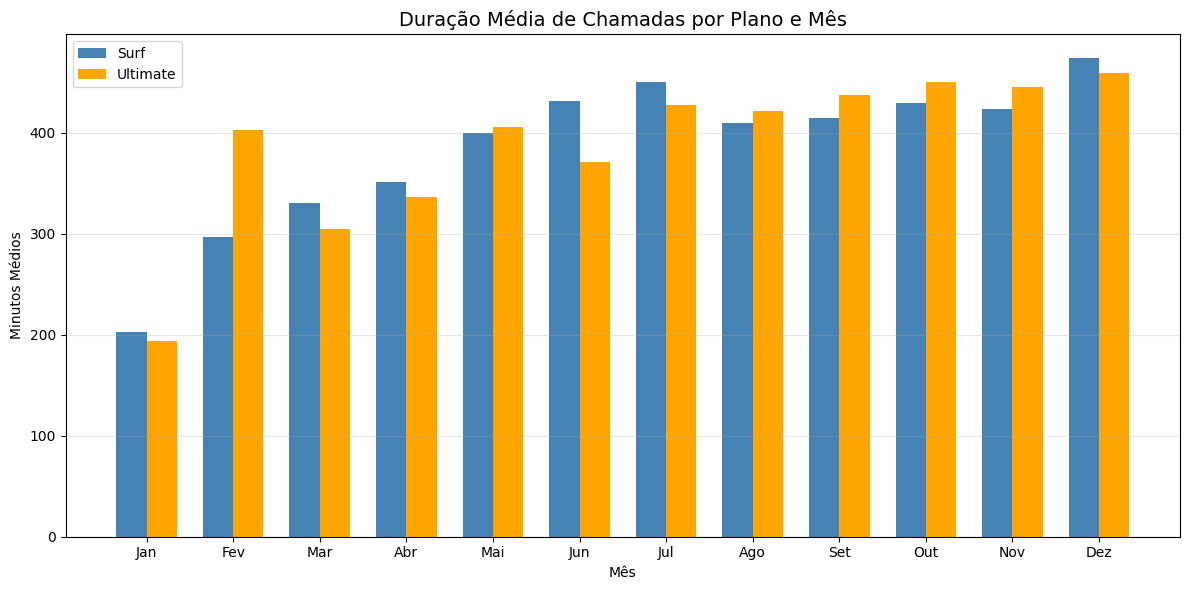

plan     surf  ultimate
month                  
1      203.00    193.50
2      297.00    403.14
3      330.00    304.25
4      351.54    336.86
5      399.58    406.24
6      431.30    370.96
7      449.98    427.07
8      410.11    421.44
9      414.23    437.51
10     429.73    450.74
11     423.33    445.20
12     473.84    459.10


In [ ]:

avg_duration = df.groupby(['plan', 'month'])['minutes_used'].mean().reset_index()

surf_avg = avg_duration[avg_duration['plan'] == 'surf']
ultimate_avg = avg_duration[avg_duration['plan'] == 'ultimate']

x = surf_avg['month']
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, surf_avg['minutes_used'], width, label='Surf', color='steelblue')
bars2 = ax.bar(x + width/2, ultimate_avg['minutes_used'], width, label='Ultimate', color='orange')

ax.set_title('Duração Média de Chamadas por Plano e Mês', fontsize=14)
ax.set_xlabel('Mês')
ax.set_ylabel('Minutos Médios')
ax.set_xticks(x)
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                     'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(avg_duration.pivot(index='month', columns='plan', values='minutes_used').round(2))



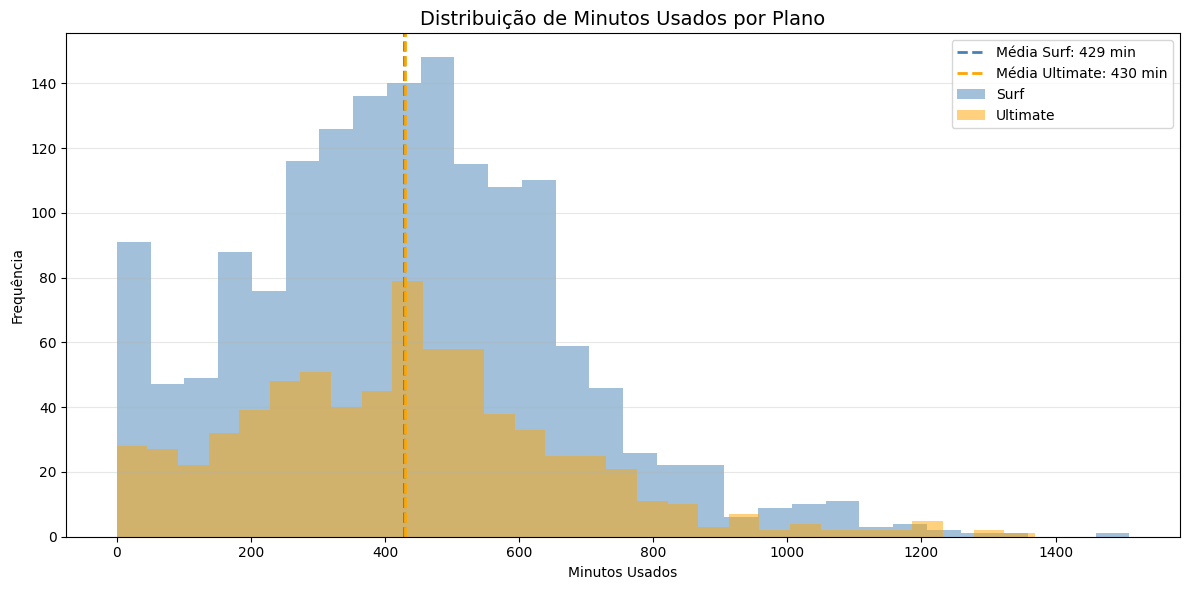

In [ ]:

surf_minutes = df[df['plan'] == 'surf']['minutes_used']
ultimate_minutes = df[df['plan'] == 'ultimate']['minutes_used']

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(surf_minutes, bins=30, alpha=0.5, label='Surf', color='steelblue')
ax.hist(ultimate_minutes, bins=30, alpha=0.5, label='Ultimate', color='orange')

ax.axvline(surf_minutes.mean(), color='steelblue', linestyle='--', linewidth=2, label=f'Média Surf: {surf_minutes.mean():.0f} min')
ax.axvline(ultimate_minutes.mean(), color='orange', linestyle='--', linewidth=2, label=f'Média Ultimate: {ultimate_minutes.mean():.0f} min')

ax.set_title('Distribuição de Minutos Usados por Plano', fontsize=14)
ax.set_xlabel('Minutos Usados')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [ ]:
# Calcule a média e a variância da duração mensal das chamadas
print("Estatísticas de minutos usados por plano:")
print()

for plan in ['surf', 'ultimate']:
    minutes = df[df['plan'] == plan]['minutes_used']
    print(f"Plano {plan.upper()}:")
    print(f"  Média:    {minutes.mean():.2f} minutos")
    print(f"  Variância: {minutes.var():.2f}")
    print(f"  Desvio padrão: {minutes.std():.2f}")
    print(f"  Mínimo:   {minutes.min():.2f}")
    print(f"  Máximo:   {minutes.max():.2f}")
    print()



Estatísticas de minutos usados por plano:

Plano SURF:
  Média:    428.75 minutos
  Variância: 54968.28
  Desvio padrão: 234.45
  Mínimo:   0.00
  Máximo:   1510.00

Plano ULTIMATE:
  Média:    430.45 minutos
  Variância: 57844.46
  Desvio padrão: 240.51
  Mínimo:   0.00
  Máximo:   1369.00



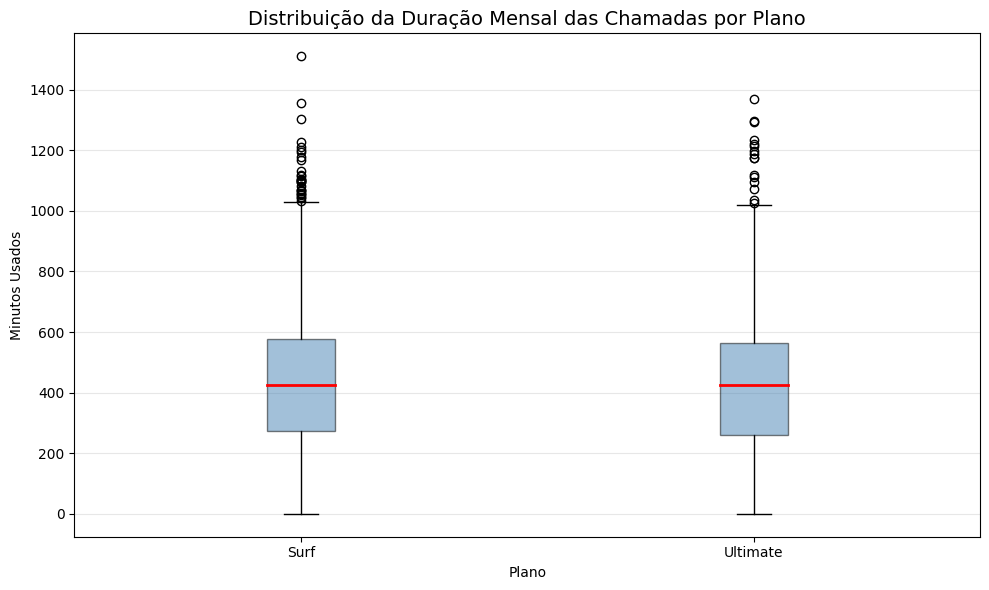

In [ ]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
fig, ax = plt.subplots(figsize=(10, 6))

surf_minutes = df[df['plan'] == 'surf']['minutes_used']
ultimate_minutes = df[df['plan'] == 'ultimate']['minutes_used']

ax.boxplot([surf_minutes, ultimate_minutes], 
           labels=['Surf', 'Ultimate'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5),
           medianprops=dict(color='red', linewidth=2))

ax.set_title('Distribuição da Duração Mensal das Chamadas por Plano', fontsize=14)
ax.set_xlabel('Plano')
ax.set_ylabel('Minutos Usados')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



[Formule conclusões sobre como os usuários se comportam em termos de chamadas. O comportamento é diferente dependendo do plano?]

### Mensagens

Estatísticas de mensagens enviadas por plano:

Plano SURF:
  Média:         31.16 mensagens
  Variância:     1126.72
  Desvio padrão: 33.57
  Mínimo:        0
  Máximo:        266

Plano ULTIMATE:
  Média:         37.55 mensagens
  Variância:     1208.76
  Desvio padrão: 34.77
  Mínimo:        0
  Máximo:        166



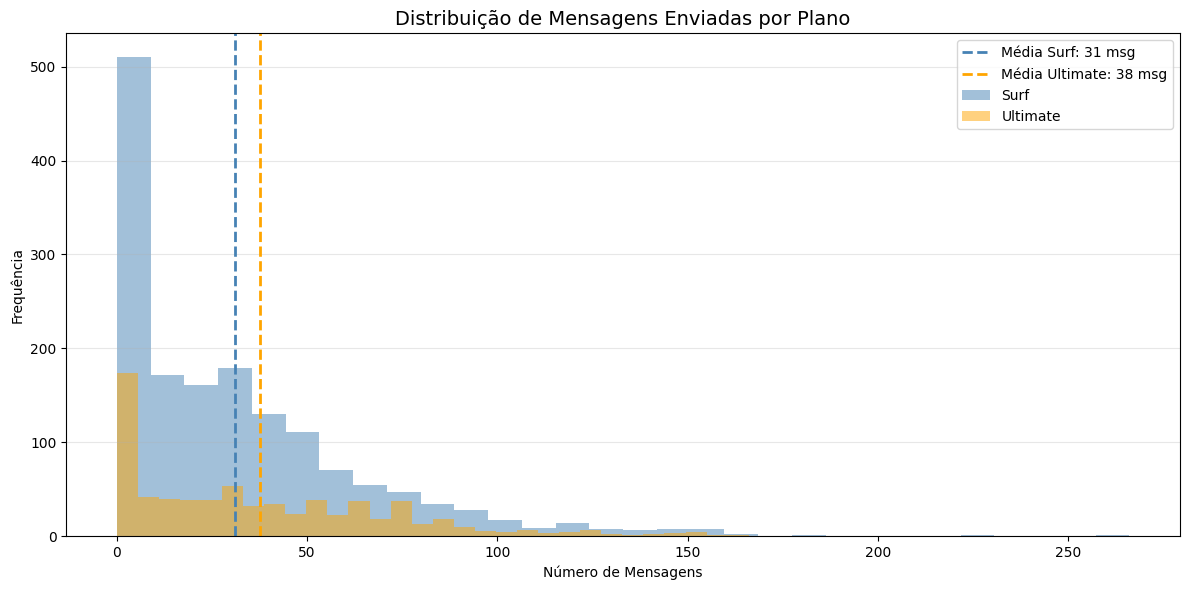

In [ ]:

surf_messages = df[df['plan'] == 'surf']['messages_count']
ultimate_messages = df[df['plan'] == 'ultimate']['messages_count']

print("Estatísticas de mensagens enviadas por plano:")
print()
for plan, messages in [('SURF', surf_messages), ('ULTIMATE', ultimate_messages)]:
    print(f"Plano {plan}:")
    print(f"  Média:         {messages.mean():.2f} mensagens")
    print(f"  Variância:     {messages.var():.2f}")
    print(f"  Desvio padrão: {messages.std():.2f}")
    print(f"  Mínimo:        {messages.min():.0f}")
    print(f"  Máximo:        {messages.max():.0f}")
    print()


fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(surf_messages, bins=30, alpha=0.5, label='Surf', color='steelblue')
ax.hist(ultimate_messages, bins=30, alpha=0.5, label='Ultimate', color='orange')

ax.axvline(surf_messages.mean(), color='steelblue', linestyle='--', linewidth=2, label=f'Média Surf: {surf_messages.mean():.0f} msg')
ax.axvline(ultimate_messages.mean(), color='orange', linestyle='--', linewidth=2, label=f'Média Ultimate: {ultimate_messages.mean():.0f} msg')

ax.set_title('Distribuição de Mensagens Enviadas por Plano', fontsize=14)
ax.set_xlabel('Número de Mensagens')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Estatísticas de internet consumida por plano:

Plano SURF:
  Média:         16577.76 MB (16.19 GB)
  Variância:     64343620.22
  Desvio padrão: 8021.45
  Mínimo:        0 MB
  Máximo:        70988 MB

Plano ULTIMATE:
  Média:         17234.64 MB (16.83 GB)
  Variância:     61765502.66
  Desvio padrão: 7859.10
  Mínimo:        0 MB
  Máximo:        46634 MB



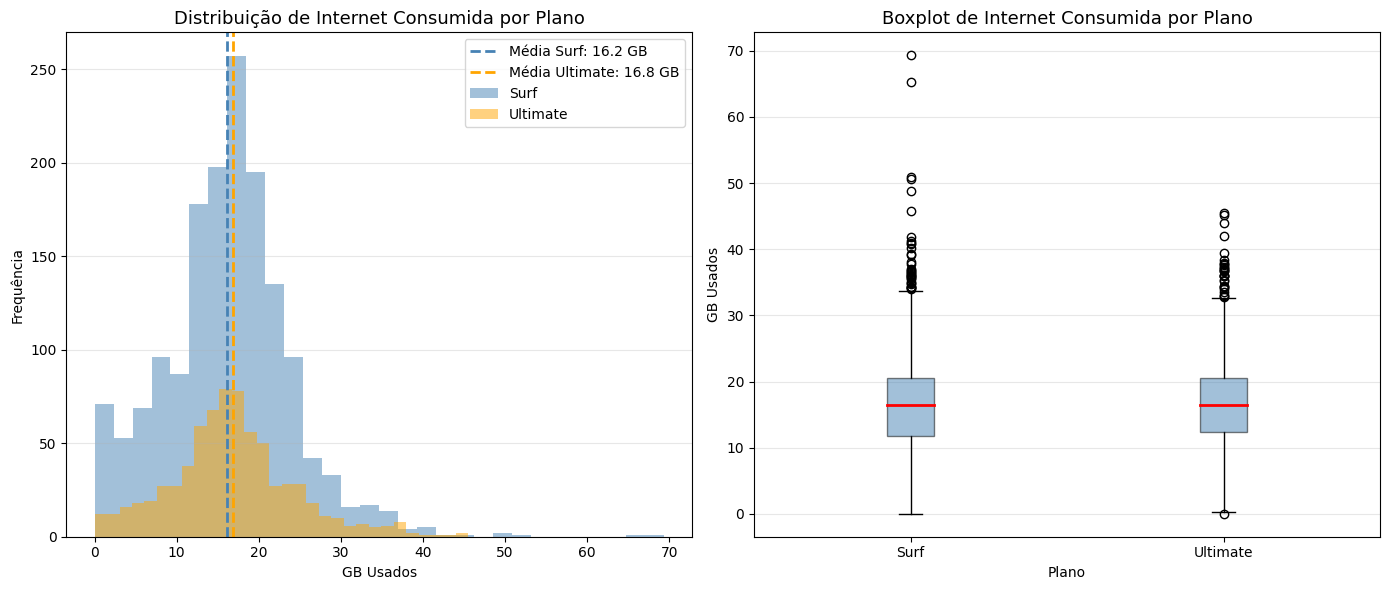

In [ ]:

surf_internet = df[df['plan'] == 'surf']['mb_used']
ultimate_internet = df[df['plan'] == 'ultimate']['mb_used']

print("Estatísticas de internet consumida por plano:")
print()
for plan, internet in [('SURF', surf_internet), ('ULTIMATE', ultimate_internet)]:
    print(f"Plano {plan}:")
    print(f"  Média:         {internet.mean():.2f} MB ({internet.mean()/1024:.2f} GB)")
    print(f"  Variância:     {internet.var():.2f}")
    print(f"  Desvio padrão: {internet.std():.2f}")
    print(f"  Mínimo:        {internet.min():.0f} MB")
    print(f"  Máximo:        {internet.max():.0f} MB")
    print()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].hist(surf_internet/1024, bins=30, alpha=0.5, label='Surf', color='steelblue')
axes[0].hist(ultimate_internet/1024, bins=30, alpha=0.5, label='Ultimate', color='orange')
axes[0].axvline(surf_internet.mean()/1024, color='steelblue', linestyle='--', linewidth=2, 
                label=f'Média Surf: {surf_internet.mean()/1024:.1f} GB')
axes[0].axvline(ultimate_internet.mean()/1024, color='orange', linestyle='--', linewidth=2, 
                label=f'Média Ultimate: {ultimate_internet.mean()/1024:.1f} GB')
axes[0].set_title('Distribuição de Internet Consumida por Plano', fontsize=13)
axes[0].set_xlabel('GB Usados')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)


axes[1].boxplot([surf_internet/1024, ultimate_internet/1024],
                labels=['Surf', 'Ultimate'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot de Internet Consumida por Plano', fontsize=13)
axes[1].set_xlabel('Plano')
axes[1].set_ylabel('GB Usados')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



[Formule conclusões sobre como os usuários costumam consumir o tráfego da internet. O comportamento é diferente dependendo do plano?] Com base nas estatísticas e gráficos gerados, podemos observar que:

Os usuários do plano **Surf** consomem em média **16.19 GB** por mês, 
ultrapassando o limite de **15 GB inclusos**. Isso indica que boa parte 
dos usuários paga excedentes de **$10/GB**, contribuindo para uma receita 
adicional relevante para a empresa.

Os usuários do plano **Ultimate** consomem em média **16.83 GB** por mês, 
bem abaixo do limite de **30 GB inclusos**. Isso significa que raramente 
pagam excedentes de internet.

A **variância** é muito alta nos dois planos, com desvio padrão de 
aproximadamente **8 GB**, mostrando grande dispersão no consumo entre usuários.

Em termos de comportamento, os dois planos são **bastante similares** em 
consumo médio, mas usuários Surf pagam mais pelo excedente devido ao limite 
menor e preço mais alto por GB.

### Internet

In [ ]:
surf_internet = df[df['plan'] == 'surf']['mb_used']
ultimate_internet = df[df['plan'] == 'ultimate']['mb_used']

print("Estatísticas de internet consumida por plano:")
print()
for plan, internet in [('SURF', surf_internet), ('ULTIMATE', ultimate_internet)]:
    print(f"Plano {plan}:")
    print(f"  Média:         {internet.mean():.2f} MB ({internet.mean()/1024:.2f} GB)")
    print(f"  Variância:     {internet.var():.2f}")
    print(f"  Desvio padrão: {internet.std():.2f}")
    print(f"  Mínimo:        {internet.min():.0f} MB")
    print(f"  Máximo:        {internet.max():.0f} MB")
    print()

Estatísticas de internet consumida por plano:

Plano SURF:
  Média:         16577.76 MB (16.19 GB)
  Variância:     64343620.22
  Desvio padrão: 8021.45
  Mínimo:        0 MB
  Máximo:        70988 MB

Plano ULTIMATE:
  Média:         17234.64 MB (16.83 GB)
  Variância:     61765502.66
  Desvio padrão: 7859.10
  Mínimo:        0 MB
  Máximo:        46634 MB



[Formule conclusões sobre como os usuários tendem a consumir o tráfego da internet. O comportamento é diferente dependendo do plano?] Os usuários do plano **Surf** consomem em média **16.19 GB** por mês, 
ultrapassando o limite de **15 GB inclusos**, o que gera excedentes frequentes 
a **$10/GB**. Já os usuários do plano **Ultimate** consomem em média **16.83 GB**, 
bem abaixo do limite de **30 GB**, raramente pagando excedentes.

Apesar do consumo médio ser similar entre os planos, o alto desvio padrão 
de aproximadamente **8 GB** em ambos indica grande variação entre usuários. 
O comportamento é parecido, mas o impacto financeiro é muito diferente — 
usuários Surf pagam mais pelo mesmo consumo.

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

In [ ]:
surf_revenue = df[df['plan'] == 'surf']['revenue']
ultimate_revenue = df[df['plan'] == 'ultimate']['revenue']

print("Estatísticas de receita por plano:")
print()
for plan, revenue in [('SURF', surf_revenue), ('ULTIMATE', ultimate_revenue)]:
    print(f"Plano {plan}:")
    print(f"  Média:         ${revenue.mean():.2f}")
    print(f"  Variância:     ${revenue.var():.2f}")
    print(f"  Desvio padrão: ${revenue.std():.2f}")
    print(f"  Mínimo:        ${revenue.min():.2f}")
    print(f"  Máximo:        ${revenue.max():.2f}")
    print()

Estatísticas de receita por plano:

Plano SURF:
  Média:         $60.80
  Variância:     $3074.74
  Desvio padrão: $55.45
  Mínimo:        $20.00
  Máximo:        $590.37

Plano ULTIMATE:
  Média:         $72.33
  Variância:     $132.21
  Desvio padrão: $11.50
  Mínimo:        $70.00
  Máximo:        $182.00



Com base nas estatísticas de receita geradas, podemos observar que:

O plano **Surf** gera uma receita média de **$60.80** por usuário por mês, 
abaixo da mensalidade do plano **Ultimate** de **$72.33**. Porém, o que chama 
atenção é a enorme **variância do Surf ($3074.74)** comparada à do Ultimate 
(**$132.21**), o que indica que os usuários Surf têm um comportamento de consumo 
muito irregular.

O desvio padrão do plano **Surf é de $55.45**, contra apenas **$11.50** do 
**Ultimate**, confirmando que a receita gerada pelos usuários Surf é muito 
mais imprevisível — alguns pagam apenas a mensalidade mínima de **$20.00** 
enquanto outros chegam a pagar até **$590.37** em excedentes.

Já o plano **Ultimate** é muito mais estável, com receita variando entre 
**$70.00** e **$182.00**, pois a maioria dos usuários raramente ultrapassa 
os limites inclusos.

Em resumo, o plano **Ultimate** gera uma receita mais previsível e estável, 
enquanto o plano **Surf** pode gerar receitas maiores em casos extremos, mas 
com muito mais variação entre os usuários.

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [ ]:

alpha = 0.05


surf_revenue = df[df['plan'] == 'surf']['revenue']
ultimate_revenue = df[df['plan'] == 'ultimate']['revenue']

t_stat, p_value = stats.ttest_ind(surf_revenue, ultimate_revenue)

print("Teste de Hipótese: Receita Surf vs Ultimate")
print()
print(f"H0: A receita média dos dois planos são iguais")
print(f"H1: A receita média dos dois planos são diferentes")
print()
print(f"Nível de significância (alfa): {alpha}")
print(f"Estatística t: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()
if p_value < alpha:
    print("Resultado: REJEITAMOS H0 — há diferença significativa entre as receitas dos planos.")
else:
    print("Resultado: NÃO rejeitamos H0 — não há diferença significativa entre as receitas dos planos.")


Teste de Hipótese: Receita Surf vs Ultimate

H0: A receita média dos dois planos são iguais
H1: A receita média dos dois planos são diferentes

Nível de significância (alfa): 0.05
Estatística t: -5.5285
P-value: 0.0000

Resultado: REJEITAMOS H0 — há diferença significativa entre as receitas dos planos.


[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [ ]:

alpha = 0.05


nynj_revenue = df[df['city'].str.contains('NY-NJ', na=False)]['revenue']
other_revenue = df[~df['city'].str.contains('NY-NJ', na=False)]['revenue']

t_stat, p_value = stats.ttest_ind(nynj_revenue, other_revenue)

print("Teste de Hipótese: Receita NY-NJ vs Demais Regiões")
print()
print(f"H0: A receita média dos usuários de NY-NJ é igual à dos demais")
print(f"H1: A receita média dos usuários de NY-NJ é diferente à dos demais")
print()
print(f"Usuários NY-NJ: {len(nynj_revenue)}")
print(f"Usuários demais regiões: {len(other_revenue)}")
print()
print(f"Média NY-NJ:          ${nynj_revenue.mean():.2f}")
print(f"Média demais regiões: ${other_revenue.mean():.2f}")
print()
print(f"Nível de significância (alfa): {alpha}")
print(f"Estatística t: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()
if p_value < alpha:
    print("Resultado: REJEITAMOS H0 — há diferença significativa entre a receita de NY-NJ e demais regiões.")
else:
    print("Resultado: NÃO rejeitamos H0 — não há diferença significativa entre a receita de NY-NJ e demais regiões.")


Teste de Hipótese: Receita NY-NJ vs Demais Regiões

H0: A receita média dos usuários de NY-NJ é igual à dos demais
H1: A receita média dos usuários de NY-NJ é diferente à dos demais

Usuários NY-NJ: 377
Usuários demais regiões: 1916

Média NY-NJ:          $60.00
Média demais regiões: $65.29

Nível de significância (alfa): 0.05
Estatística t: -2.0114
P-value: 0.0444

Resultado: REJEITAMOS H0 — há diferença significativa entre a receita de NY-NJ e demais regiões.


## Conclusão geral

Com base na análise exploratória e estatística dos dados da Megaline em 2018, conclui-se que o plano **Ultimate** é, em média, o mais rentável por usuário, com receita média de **US$ 72,33**, contra **US$ 60,80** no plano **Surf**. Embora os clientes de ambos os planos apresentem comportamento semelhante de uso em chamadas e internet (médias próximas), a estrutura de franquias e excedentes afeta o resultado financeiro: no **Surf**, o consumo médio de internet (**16,19 GB**) ultrapassa o limite incluído de 15 GB, gerando cobranças adicionais com frequência; no **Ultimate**, apesar do consumo médio ligeiramente maior (**16,83 GB**), os usuários ficam bem abaixo da franquia de 30 GB e pagam menos excedentes.

A receita do Surf é mais volátil (desvio padrão de **US$ 55,45**, máximo de **US$ 590,37**), enquanto o Ultimate é mais estável e previsível (desvio padrão de **US$ 11,50**). Os testes de hipótese confirmam diferença estatisticamente significativa entre as receitas médias dos planos (**p-value < 0,05**) e também entre a região NY-NJ e as demais regiões (**p-value = 0,0444**).

Portanto, para fins de planejamento comercial e orçamento, a recomendação é priorizar o **plano Ultimate** como principal gerador de receita média e previsibilidade, mantendo o Surf como plano de entrada com potencial de picos de receita por excedente, porém com maior incerteza.